# Lidar–VectorNav Sync Workbench

This notebook starts the implementation of per-window timing-offset estimation for lidar vertical stares against continuous VectorNav `VelNED2`.

The initial implementation covers:

- project setup and shared imports
- cached lidar chunk/file bookkeeping
- periodic beam buffers and single-file reads
- chunk extraction with the existing `fit_offset` prior
- mdv-based sync signal construction using the `1.03` intensity threshold
- FFT bandpass filtering, analytic-envelope construction, and FFT cross-correlation
- one-window diagnostics for coarse and fine timing estimates

Later cells can extend this to multi-window continuity priors, jump detection, and production integration.

In [1]:
# setup
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Statistics
using StatsBase
using Rotations
using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf
using PyPlot

include("./read_lidar.jl")
using .read_lidar
using .read_lidar.stare
using .read_vecnav: read_vecnav_dict
import .chunks
read_stare_time = Main.chunks.read_stare_time
read_stare_chunk = Main.chunks.read_stare_chunk
fit_offset = Main.chunks.fit_offset

include("./timing_lidar.jl")
using .timing_lidar

pd = permutedims

  Activating project at `~/Projects/lidar/ASTRAL2024`


permutedims (generic function with 21 methods)

In [2]:
# constants and small utilities
const NOISE_THR = 1.03
const BANDPASS_PERIOD = (5.0, 20.0)
const BANDPASS_HZ = (1 / BANDPASS_PERIOD[2], 1 / BANDPASS_PERIOD[1])
const TIMESTEP = 1.02
const RANGEGATE = 24.0

m2n(x) = ismissing(x) ? NaN : x
good(x) = !ismissing(x) && isfinite(x)
isgoodnum(x) = !ismissing(x) && isfinite(x)
anom(x) = x .- mean(x)

masklowi(x, i, thr=NOISE_THR) = i < thr ? missing : x

function findindices(xs, xl)
    isempty(xs) && return Int[]
    isempty(xl) && return Int[]
    xs = filter(x -> x <= last(xl), xs)
    ind = zeros(Int, size(xs))
    i = 1
    for (j, x) in enumerate(xs)
        while i < length(xl) && xl[i] < x
            i += 1
        end
        ind[j] = i
    end
    ind
end

function indavg(xl, ind; full=20)
    xm = zeros(Float64, size(ind))
    for (i, idx) in enumerate(ind)
        ii = max(1, idx):min(length(xl), idx + full)
        xm[i] = mean(Float64.(xl[ii]))
    end
    xm
end

function diag_array(name, A)
    v = vec(A)
    @printf("%-12s size=%-14s missing=%6d finite=%6d nan=%6d\n",
        name,
        string(size(A)),
        count(ismissing, v),
        count(isgoodnum, v),
        count(x -> !ismissing(x) && isnan(x), v),
    )
end

function valid_chunk_mdv(intensity, dopplervel; thr=NOISE_THR)
    valid = (.!ismissing.(dopplervel)) .& isfinite.(coalesce.(dopplervel, NaN)) .& (.!ismissing.(intensity)) .& (coalesce.(intensity, -Inf) .> thr)
    goodlevels = findall(vec(all(valid, dims=1)))
    nt = size(dopplervel, 1)
    if isempty(goodlevels)
        return fill(NaN, nt), goodlevels
    end
    chunkmedian = median(skipmissing(vec(dopplervel[:, goodlevels])))
    timeslicemedian = vec(mapslices(x -> median(skipmissing(x)), dopplervel[:, goodlevels], dims=2))
    return timeslicemedian .- chunkmedian, goodlevels
end

valid_chunk_mdv (generic function with 1 method)

In [3]:
# periodic buffer types and lidar file bookkeeping
_wrap(x::Integer, n::Int) = mod1(x, n)
_wrap(x::AbstractRange{<:Integer}, n::Int) = mod1.(collect(x), n)
_wrap(x::AbstractArray{<:Integer}, n::Int) = mod1.(x, n)
_wrap(::Colon, ::Int) = (:)

struct PeriodicVector{T}
    data::Vector{T}
end

Base.size(p::PeriodicVector) = size(p.data)
Base.length(p::PeriodicVector) = length(p.data)
Base.getindex(p::PeriodicVector, i) = getindex(p.data, _wrap(i, length(p.data)))
Base.setindex!(p::PeriodicVector, v, i) = setindex!(p.data, v, _wrap(i, length(p.data)))
Base.setindex!(p::PeriodicVector, v::AbstractVector, i::Union{AbstractVector, AbstractRange}) = (p.data[_wrap(i, length(p.data))] .= v)

struct PeriodicMatrix{T}
    data::Matrix{T}
end

Base.size(p::PeriodicMatrix) = size(p.data)
Base.getindex(p::PeriodicMatrix, i, j...) = getindex(p.data, _wrap(i, size(p.data, 1)), j...)
Base.setindex!(p::PeriodicMatrix, v, i, j...) = setindex!(p.data, v, _wrap(i, size(p.data, 1)), j...)
Base.setindex!(p::PeriodicMatrix, v::AbstractArray, i::Union{AbstractVector, AbstractRange}, j...) = (p.data[_wrap(i, size(p.data, 1)), j...] .= v)

function init_periodic_beams(nbeams, ngates)
    PeriodicVectorMissing(n) = PeriodicVector(Vector{Union{Float32, Missing}}(fill(missing, n)))
    PeriodicMatrixMissing(nrows, ncols) = PeriodicMatrix(Matrix{Union{Float32, Missing}}(fill(missing, nrows, ncols)))
    VectorMissing(n) = Vector{Union{Float32, Missing}}(fill(missing, n))
    Dict(
        :time => PeriodicVectorMissing(nbeams),
        :azimuth => PeriodicVectorMissing(nbeams),
        :elevangle => PeriodicVectorMissing(nbeams),
        :pitch => PeriodicVectorMissing(nbeams),
        :roll => PeriodicVectorMissing(nbeams),
        :height => VectorMissing(ngates),
        :dopplervel => PeriodicMatrixMissing(nbeams, ngates),
        :intensity => PeriodicMatrixMissing(nbeams, ngates),
        :beta => PeriodicMatrixMissing(nbeams, ngates),
    )
end

function load_lidar_indices_and_files(; lidarstemdir="./data")
    if isfile("lidar_dt.jld2")
        lidardt = load("lidar_dt.jld2")
    else
        error("Expected lidar_dt.jld2 to exist. Generate it with save_lidar_dt.jl before using this workbench.")
    end
    if isfile("file_beam_inds.jld2")
        fileinds = load("file_beam_inds.jld2")
    else
        error("Expected file_beam_inds.jld2 to exist. Generate it from the production workflow before using this workbench.")
    end
    starefiles = filter(startswith("Stare_116_"), readdir(joinpath(lidarstemdir, "all")))
    ff = joinpath.(lidarstemdir, "all", starefiles)
    return (;
        LidarDt=lidardt,
        FileInds=fileinds,
        ff,
        ists=lidardt["ist"],
        iens=lidardt["ien"],
        dtime=lidardt["dtime"],
        bigind_file_starts=fileinds["bigind_file_start"],
        bigind_file_ends=fileinds["bigind_file_end"],
    )
end

load_lidar_indices_and_files (generic function with 1 method)

In [4]:
# beam reader and external datasets
function read_streamlinexr_stare!(file_path, h, beams, bb, nheaderlines=17; startat=1, endat=0)
    nz = size(beams[:height][:], 1)
    nlines = h[:nlines]
    ngates = h[:ngates]
    nbeamsmax = round(Int, (nlines - nheaderlines) / (1 + ngates))
    endat = endat == 0 ? nbeamsmax : mod(endat - 1, nbeamsmax) + 1
    nbeams = min(endat - startat + 1, nbeamsmax)

    beam_timeangles = zeros(Float64, nbeams, 5)
    beam_velrad = zeros(Float64, nbeams, ngates, 4)

    open(file_path) do file
        for _ in 1:nheaderlines
            readline(file)
        end
        for _ in 1:((1 + ngates) * (startat - 1))
            readline(file)
        end
        for ibeam in 1:nbeams
            beam_timeangles[ibeam, :] .= parse.(Float64, split(readline(file)))
            for igate in 1:ngates
                beam_velrad[ibeam, igate, :] .= parse.(Float64, split(readline(file)))
            end
        end
    end

    setindex!(beams[:time], beam_timeangles[:, 1], bb)
    setindex!(beams[:azimuth], beam_timeangles[:, 2], bb)
    setindex!(beams[:elevangle], beam_timeangles[:, 3], bb)
    setindex!(beams[:pitch], beam_timeangles[:, 4], bb)
    setindex!(beams[:roll], beam_timeangles[:, 5], bb)
    beams[:height][1:nz] .= (beam_velrad[1, 1:nz, 1] .+ 0.5) .* h[:gatelength]
    setindex!(beams[:dopplervel], beam_velrad[:, 1:nz, 2], bb, 1:nz)
    setindex!(beams[:intensity], beam_velrad[:, 1:nz, 3], bb, 1:nz)
    setindex!(beams[:beta], beam_velrad[:, 1:nz, 4], bb, 1:nz)
    nothing
end

Env = load_lidar_indices_and_files()
Vn = read_vecnav_dict()
UV = NCDataset(joinpath("data/netcdf", "ekamsat_lidar_uv_20240428-20240613.nc"))

dtime_st = Env.dtime[Env.ists]
dtime_en = Env.dtime[Env.iens]
icvn = findfirst(dtime_st .>= Vn[:vndt][1]):findlast(dtime_en .<= Vn[:vndt][end])

nx = 4000
nz = 80
beams = init_periodic_beams(nx, nz)

Dict{Symbol, Any} with 9 entries:
  :time       => PeriodicVector{Union{Missing, Float32}}(Union{Missing, Float32…
  :dopplervel => PeriodicMatrix{Union{Missing, Float32}}(Union{Missing, Float32…
  :roll       => PeriodicVector{Union{Missing, Float32}}(Union{Missing, Float32…
  :beta       => PeriodicMatrix{Union{Missing, Float32}}(Union{Missing, Float32…
  :elevangle  => PeriodicVector{Union{Missing, Float32}}(Union{Missing, Float32…
  :azimuth    => PeriodicVector{Union{Missing, Float32}}(Union{Missing, Float32…
  :height     => Union{Missing, Float32}[missing, missing, missing, missing, mi…
  :intensity  => PeriodicMatrix{Union{Missing, Float32}}(Union{Missing, Float32…
  :pitch      => PeriodicVector{Union{Missing, Float32}}(Union{Missing, Float32…

In [12]:
# synchronization helpers
function init_stream_state()
    Dict(
        :ifile_loaded => 0,
        :bigind_file_end => 0,
    )
end

function ensure_chunk_loaded!(beams, env, state, ic)
    ist = env.ists[ic]
    ien = env.iens[ic]
    ifile_needed = findlast(env.bigind_file_starts .<= ist)
    isnothing(ifile_needed) && error("No file contains ist=$(ist)")

    if state[:ifile_loaded] == 0
        state[:ifile_loaded] = ifile_needed - 1
        state[:bigind_file_end] = 0
    end

    while (state[:ifile_loaded] < ifile_needed) || (ien > state[:bigind_file_end])
        state[:ifile_loaded] += 1
        state[:ifile_loaded] > length(env.ff) && error("Ran out of lidar files while loading chunk ic=$(ic)")

        ifile = state[:ifile_loaded]
        bb = env.bigind_file_starts[ifile]:env.bigind_file_ends[ifile]
        h = read_lidar.read_streamlinexr_head(env.ff[ifile])
        read_streamlinexr_stare!(env.ff[ifile], h, beams, bb)
        state[:bigind_file_end] = env.bigind_file_ends[ifile]
    end

    return (; ifile=ifile_needed, ist, ien)
end

function chunk_lidar_datetimes(dt_chunk, beams, ist, ien)
    stare_dt_raw = @. DateTime(Date(dt_chunk)) + Millisecond(round(Int64, beams[:time][ist:ien] * 3_600_000))
    lidar_clock_fast_by = Millisecond(round(Int64, 1_000 * fit_offset(stare_dt_raw[1])))
    stare_dt = stare_dt_raw .- lidar_clock_fast_by
    return stare_dt_raw, stare_dt, lidar_clock_fast_by
end

function extract_sync_window(beams, env, state, Vn, UV, ic; ntop=80)
    info = ensure_chunk_loaded!(beams, env, state, ic)
    dopplervel, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv_builtin = read_stare_chunk(info.ist <= length(env.dtime) ? env.dtime[info.ist] : env.dtime[end], beams, Vn, UV, info.ist, info.ien, ntop)
    stare_dt_raw, stare_dt, lidar_clock_fast_by = chunk_lidar_datetimes(env.dtime[info.ist], beams, info.ist, info.ien)
    intensity = beams[:intensity][info.ist:info.ien, 1:ntop]
    beta = beams[:beta][info.ist:info.ien, 1:ntop]
    mdv, goodlevels = valid_chunk_mdv(intensity, dopplervel)
    return (; info..., stare_dt_raw, stare_dt, lidar_clock_fast_by, dopplervel, intensity, beta, pitch, roll, vn0, vn1, vn2, Ur, Vr, mdv, mdv_builtin, goodlevels)
end

function finite_overlap(x, y)
    keep = isfinite.(x) .& isfinite.(y)
    return x[keep], y[keep], keep
end

function detrend_center(x)
    y = Float64.(x)
    y .-= mean(y)
    y
end

function shift_signal_linear(x, lag_seconds; dt=TIMESTEP, fill_value=NaN)
    y = Float64.(x)
    n = length(y)
    q = collect(1:n) .- lag_seconds / dt
    out = fill(fill_value, n)
    for i in eachindex(q)
        qi = q[i]
        if 1 <= qi <= n
            lo = floor(Int, qi)
            hi = ceil(Int, qi)
            if lo == hi
                out[i] = y[lo]
            else
                w = qi - lo
                out[i] = (1 - w) * y[lo] + w * y[hi]
            end
        end
    end
    out
end

function real_fft_frequencies(n, fs)
    collect(0:div(n, 2)) .* (fs / n)
end

function cosine_edge_mask(freq, flo, fhi; frac=0.15)
    mask = zeros(Float64, length(freq))
    width = max((fhi - flo) * frac, eps())
    lo1 = max(0.0, flo - width)
    hi2 = fhi + width
    for i in eachindex(freq)
        f = freq[i]
        if flo <= f <= fhi
            mask[i] = 1.0
        elseif lo1 <= f < flo
            mask[i] = 0.5 * (1 - cos(pi * (f - lo1) / max(flo - lo1, eps())))
        elseif fhi < f <= hi2
            mask[i] = 0.5 * (1 + cos(pi * (f - fhi) / max(hi2 - fhi, eps())))
        end
    end
    mask
end

function fft_bandpass(x; dt=TIMESTEP, flo=BANDPASS_HZ[1], fhi=BANDPASS_HZ[2], taper_frac=0.1)
    n = length(x)
    n < 8 && return fill(NaN, n)
    xt = detrend_center(x)
    taper = DSP.Windows.tukey(n, taper_frac)
    xf = rfft(xt .* taper)
    freq = real_fft_frequencies(n, 1 / dt)
    mask = cosine_edge_mask(freq, flo, fhi)
    irfft(xf .* mask, n)
end

function analytic_envelope_fft(x)
    n = length(x)
    X = fft(Float64.(x))
    h = zeros(Float64, n)
    if iseven(n)
        h[1] = 1
        h[div(n, 2) + 1] = 1
        h[2:div(n, 2)] .= 2
    else
        h[1] = 1
        h[2:div(n + 1, 2)] .= 2
    end
    abs.(ifft(X .* h))
end

function fft_xcorr_lag(x, y; dt=TIMESTEP, maxlag_seconds=120.0, center_seconds=0.0)
    xv, yv, _ = finite_overlap(Float64.(x), Float64.(y))
    n = min(length(xv), length(yv))
    n < 8 && return (lag_seconds=NaN, peak=NaN, peak_norm=NaN, lags=Float64[], corr=Float64[])

    xuse = detrend_center(xv[1:n])
    yuse = detrend_center(yv[1:n])
    nfft = nextpow(2, 2 * n - 1)
    xpad = vcat(xuse, zeros(nfft - n))
    ypad = vcat(yuse, zeros(nfft - n))
    cc = ifft(fft(xpad) .* conj(fft(ypad)))
    corr = real(vcat(cc[end - (n - 2):end], cc[1:n]))
    lags = collect(-(n - 1):(n - 1)) .* dt

    keep = abs.(lags .- center_seconds) .<= maxlag_seconds
    corrw = corr[keep]
    lagsw = lags[keep]
    isempty(corrw) && return (lag_seconds=NaN, peak=NaN, peak_norm=NaN, lags=Float64[], corr=Float64[])

    peak, idx = findmax(corrw)
    denom = sqrt(sum(abs2, xuse) * sum(abs2, yuse))
    peak_norm = denom > 0 ? peak / denom : NaN
    return (lag_seconds=lagsw[idx], peak=peak, peak_norm=peak_norm, lags=lagsw, corr=corrw)
end

function iterative_coarse_lag(mdv_bp, vn2_bp; dt=TIMESTEP, prior_seconds=0.0, max_passes=4, search_seconds=12.0, tol_seconds=0.25, min_improve=1e-3)
    mdv_env = analytic_envelope_fft(mdv_bp)
    offset = prior_seconds
    history = NamedTuple[]
    prev_score = -Inf

    for pass in 1:max_passes
        vn2_bp_shifted = shift_signal_linear(vn2_bp, offset; dt=dt)
        vn2_env_shifted = analytic_envelope_fft(vn2_bp_shifted)
        coarse = fft_xcorr_lag(mdv_env, vn2_env_shifted; dt=dt, center_seconds=0.0, maxlag_seconds=search_seconds)
        improvement = pass == 1 || !isfinite(prev_score) ? Inf : coarse.peak_norm - prev_score
        push!(history, (;
            pass,
            offset_in=offset,
            residual=coarse.lag_seconds,
            peak=coarse.peak,
            peak_norm=coarse.peak_norm,
            improvement,
        ))

        if !isfinite(coarse.lag_seconds)
            break
        end

        offset += coarse.lag_seconds
        prev_score = coarse.peak_norm

        if abs(coarse.lag_seconds) <= tol_seconds
            break
        end
        if pass > 1 && isfinite(improvement) && improvement < min_improve
            break
        end
    end

    vn2_bp_coarse = shift_signal_linear(vn2_bp, offset; dt=dt)
    vn2_env_coarse = analytic_envelope_fft(vn2_bp_coarse)
    return (; coarse_offset=offset, mdv_env, vn2_bp_coarse, vn2_env_coarse, history)
end

function robust_center(x)
    isempty(x) ? NaN : median(x)
end

function prior_from_history(history, start_dt; recent_window=Minute(10))
    if isempty(history)
        return (; prior_seconds=0.0, previous_offset=NaN, recent_offset=NaN, parent_offset=NaN)
    end

    previous_offset = history[end].final_offset
    recent_offsets = [h.final_offset for h in history if start_dt - h.start_dt <= recent_window]
    parent_start = floor(start_dt, Hour)
    parent_offsets = [h.final_offset for h in history if floor(h.start_dt, Hour) == parent_start]

    recent_offset = robust_center(recent_offsets)
    parent_offset = robust_center(parent_offsets)

    values = Float64[]
    weights = Float64[]
    if isfinite(previous_offset)
        push!(values, previous_offset); push!(weights, 0.55)
    end
    if isfinite(recent_offset)
        push!(values, recent_offset); push!(weights, 0.30)
    end
    if isfinite(parent_offset)
        push!(values, parent_offset); push!(weights, 0.15)
    end

    prior_seconds = isempty(values) ? 0.0 : sum(values .* weights) / sum(weights)
    return (; prior_seconds, previous_offset, recent_offset, parent_offset)
end

function coarse_and_fine_lag(mdv, vn2; dt=TIMESTEP, prior_seconds=0.0, coarse_search_seconds=12.0, max_passes=4, fine_search_seconds=4.0)
    mdv_bp = fft_bandpass(mdv; dt=dt)
    vn2_bp = fft_bandpass(vn2; dt=dt)

    coarse = iterative_coarse_lag(
        mdv_bp,
        vn2_bp;
        dt=dt,
        prior_seconds=prior_seconds,
        max_passes=max_passes,
        search_seconds=coarse_search_seconds,
    )

    fine = fft_xcorr_lag(mdv_bp, coarse.vn2_bp_coarse; dt=dt, center_seconds=0.0, maxlag_seconds=fine_search_seconds)
    final_offset = coarse.coarse_offset + fine.lag_seconds
    vn2_bp_final = shift_signal_linear(vn2_bp, final_offset; dt=dt)
    vn2_env_final = analytic_envelope_fft(vn2_bp_final)

    return (;
        prior_seconds,
        mdv_bp,
        vn2_bp,
        mdv_env=coarse.mdv_env,
        vn2_env=coarse.vn2_env_coarse,
        coarse_history=coarse.history,
        coarse_offset=coarse.coarse_offset,
        fine,
        final_offset,
        vn2_bp_coarse=coarse.vn2_bp_coarse,
        vn2_bp_final,
        vn2_env_final,
    )
end

function is_jump_candidate(prior_seconds, final_seconds, fine_peak_norm; jump_threshold_seconds=0.8, min_fine_peak=0.08)
    isfinite(prior_seconds) &&
    isfinite(final_seconds) &&
    isfinite(fine_peak_norm) &&
    abs(final_seconds - prior_seconds) >= jump_threshold_seconds &&
    fine_peak_norm >= min_fine_peak
end

function backward_jump_robustness(beams, env, state, Vn, UV, history, post_offset; ntop=80, n_back=2)
    isempty(history) && return NaN
    ntest = min(n_back, length(history))
    deltas = Float64[]
    for k in 1:ntest
        h = history[end - k + 1]
        win_prev = extract_sync_window(beams, env, state, Vn, UV, h.ic; ntop=ntop)
        back_sync = coarse_and_fine_lag(win_prev.mdv, win_prev.vn2; prior_seconds=post_offset)
        if isfinite(back_sync.final_offset) && isfinite(h.final_offset)
            push!(deltas, abs(back_sync.final_offset - h.final_offset))
        end
    end
    isempty(deltas) ? NaN : median(deltas)
end

function run_sequential_offsets(
    beams,
    env,
    Vn,
    UV,
    ic_list;
    ntop=80,
    jump_threshold_seconds=0.8,
    min_fine_peak=0.08,
    backward_windows=2,
    backward_tol=0.35,
    )
    state = init_stream_state()
    history = NamedTuple[]
    for ic in ic_list
        start_dt = env.dtime[env.ists[ic]]
        prior = prior_from_history(history, start_dt)
        win = extract_sync_window(beams, env, state, Vn, UV, ic; ntop=ntop)
        sync = coarse_and_fine_lag(win.mdv, win.vn2; prior_seconds=prior.prior_seconds)

        jump_candidate = is_jump_candidate(
            prior.prior_seconds,
            sync.final_offset,
            sync.fine.peak_norm;
            jump_threshold_seconds=jump_threshold_seconds,
            min_fine_peak=min_fine_peak,
        )

        jump_backward_metric = NaN
        jump_robust = false
        jump_accepted = false

        if jump_candidate && !isempty(history)
            post_sync = coarse_and_fine_lag(win.mdv, win.vn2; prior_seconds=sync.final_offset)
            post_offset = post_sync.final_offset

            jump_backward_metric = backward_jump_robustness(
                beams, env, state, Vn, UV, history, post_offset;
                ntop=ntop,
                n_back=backward_windows,
            )

            jump_robust = isfinite(jump_backward_metric) && jump_backward_metric <= backward_tol
            if jump_robust
                sync = post_sync
                jump_accepted = true
            else
                # fallback toward prior if the backward test does not support a clean jump
                sync = coarse_and_fine_lag(win.mdv, win.vn2; prior_seconds=prior.prior_seconds, fine_search_seconds=2.0)
            end
        end

        push!(history, (;
            ic,
            start_dt=win.stare_dt[1],
            end_dt=win.stare_dt[end],
            parent_start=floor(win.stare_dt[1], Hour),
            prior_offset=prior.prior_seconds,
            previous_offset=prior.previous_offset,
            recent_offset=prior.recent_offset,
            parent_offset=prior.parent_offset,
            coarse_offset=sync.coarse_offset,
            fine_residual=sync.fine.lag_seconds,
            final_offset=sync.final_offset,
            coarse_peak=isempty(sync.coarse_history) ? NaN : sync.coarse_history[end].peak_norm,
            fine_peak=sync.fine.peak_norm,
            goodlevels=length(win.goodlevels),
            jump_candidate,
            jump_robust,
            jump_accepted,
            jump_backward_metric,
        ))
    end
    history
end

run_sequential_offsets (generic function with 1 method)

In [14]:
# 20 Hz refinement helpers (native VN step)
function interp_datetime_linear(dt_src, y_src, dt_q)
    t_src = Float64.(Dates.datetime2epochms.(dt_src))
    t_q = Float64.(Dates.datetime2epochms.(dt_q))
    y = Float64.(y_src)

    ii = isfinite.(y)
    t = t_src[ii]
    v = y[ii]
    if length(t) < 2
        return fill(NaN, length(dt_q))
    end

    out = fill(NaN, length(t_q))
    for i in eachindex(t_q)
        tq = t_q[i]
        if tq < t[1] || tq > t[end]
            continue
        end
        j = searchsortedlast(t, tq)
        if j >= length(t)
            out[i] = v[end]
        else
            t0, t1 = t[j], t[j + 1]
            y0, y1 = v[j], v[j + 1]
            w = (tq - t0) / max(t1 - t0, eps())
            out[i] = (1 - w) * y0 + w * y1
        end
    end
    out
end

function vn_subset_20hz(stare_dt, Vn; pad=Second(2))
    ind = findall(stare_dt[1] - pad .<= Vn[:vndt] .<= stare_dt[end] + pad)
    vndt = Vn[:vndt][ind]
    vn2 = Float64.(Vn[:VelNED2][ind])
    return ind, vndt, vn2
end

function dt_seconds(dtv::Vector{DateTime})
    if length(dtv) < 2
        return NaN
    end
    d = Float64.(Dates.value.(Millisecond.(diff(dtv)))) ./ 1000
    d = d[isfinite.(d) .& (d .> 0)]
    isempty(d) ? NaN : median(d)
end

function one_hz_average_at_lidar_times(vndt20, x20, lidar_dt; half_window=0.5)
    out = fill(NaN, length(lidar_dt))
    t20 = Float64.(Dates.datetime2epochms.(vndt20))
    for i in eachindex(lidar_dt)
        tq = Float64(Dates.datetime2epochms(lidar_dt[i]))
        ii = abs.(t20 .- tq) .<= 1000 * half_window
        if any(ii)
            out[i] = mean(x20[ii])
        end
    end
    out
end

function refine_offset_20hz(win, sync_1s, Vn; coarse_search_seconds=1.0, fine_search_seconds=0.30, max_passes=3)
    _, vndt20, vn2_20 = vn_subset_20hz(win.stare_dt, Vn)
    if length(vndt20) < 20
        return (;
            final_offset_20hz=sync_1s.final_offset,
            native_step=NaN,
            final_offset_native=sync_1s.final_offset,
            final_offset_round_s=round(Int, sync_1s.final_offset),
            vn2_1s_aligned=fill(NaN, length(win.stare_dt)),
            mdv_residual_1s=fill(NaN, length(win.stare_dt)),
            sync20=nothing,
            vndt20,
            mdv20=fill(NaN, length(vndt20)),
            vn2_20,
        )
    end

    mdv20 = interp_datetime_linear(win.stare_dt, win.mdv, vndt20)
    dt20 = dt_seconds(vndt20)
    if !isfinite(dt20) || dt20 <= 0
        dt20 = 0.05
    end

    # Use negative heave so alignment objective matches mdv-heave anticorrelation.
    vn_for_fit = -vn2_20

    sync20 = coarse_and_fine_lag(
        mdv20,
        vn_for_fit;
        dt=dt20,
        prior_seconds=sync_1s.final_offset,
        coarse_search_seconds=coarse_search_seconds,
        fine_search_seconds=fine_search_seconds,
        max_passes=max_passes,
    )

    native_step = dt20
    final_native = isfinite(sync20.final_offset) ? round(sync20.final_offset / native_step) * native_step : sync_1s.final_offset
    final_round_s = round(Int, final_native)

    vn_for_fit_shifted = shift_signal_linear(vn_for_fit, final_native; dt=dt20)
    vn2_20_aligned = -vn_for_fit_shifted

    vn2_1s_aligned = one_hz_average_at_lidar_times(vndt20, vn2_20_aligned, win.stare_dt)
    mdv_residual_1s = win.mdv .+ vn2_1s_aligned

    return (;
        final_offset_20hz=sync20.final_offset,
        native_step,
        final_offset_native=final_native,
        final_offset_round_s=final_round_s,
        vn2_1s_aligned,
        mdv_residual_1s,
        sync20,
        vndt20,
        mdv20,
        vn2_20,
    )
end

refine_offset_20hz (generic function with 1 method)

In [15]:
# single-window diagnostic
kic = 1
ic = icvn[kic]
single_state = init_stream_state()
win = extract_sync_window(beams, Env, single_state, Vn, UV, ic; ntop=nz)

diag_array("dopplervel", win.dopplervel)
diag_array("intensity", win.intensity)
diag_array("Ur", win.Ur)
diag_array("Vr", win.Vr)

sync = coarse_and_fine_lag(win.mdv, win.vn2; prior_seconds=0.0)
ref20 = refine_offset_20hz(win, sync, Vn)

println("clock prior applied: ", win.lidar_clock_fast_by)
@printf("coarse offset after iterative envelope passes = %.3f s\n", sync.coarse_offset)
@printf("fine residual after coarse shift = %.3f s\n", sync.fine.lag_seconds)
@printf("final offset (1 Hz stage) = %.3f s\n", sync.final_offset)
@printf("final offset (20 Hz raw) = %.3f s\n", ref20.final_offset_20hz)
@printf("final offset (20 Hz native step) = %.3f s [step=%.3f]\n", ref20.final_offset_native, ref20.native_step)
@printf("final offset rounded to nearest second = %d s\n", ref20.final_offset_round_s)

fig = figure(figsize=(10, 11))
clf()

subplot(5, 1, 1)
pcolormesh((beams[:time][win.ist:win.ien] .% 1) .* 60, beams[:height] ./ 1e3, pd(win.beta), cmap=ColorMap("RdYlBu_r"))
ylabel("height (km)")
title("Chunk $(ic): backscatter")
colorbar()

subplot(5, 1, 2)
plot(win.stare_dt, win.mdv, label="mdv")
plot(win.stare_dt, win.vn2, label="VelNED2")
ylabel("m s^-1")
title("Raw sync signals")
legend()
grid(true)

subplot(5, 1, 3)
plot(win.stare_dt, sync.mdv_env, label="mdv envelope")
plot(win.stare_dt, sync.vn2_env, label="VelNED2 envelope after coarse shift")
ylabel("arb")
title("Envelope signals used for iterative coarse alignment")
legend()
grid(true)

subplot(5, 1, 4)
plot(win.stare_dt, sync.mdv_bp, label="mdv bandpassed")
plot(win.stare_dt, sync.vn2_bp_coarse, label="VelNED2 after coarse shift")
plot(win.stare_dt, sync.vn2_bp_final, label="VelNED2 after final shift", alpha=0.8)
ylabel("arb")
title("Real bandpassed signals used for fine FFT cross-correlation")
legend()
grid(true)

subplot(5, 1, 5)
plot(win.stare_dt, win.mdv, label="mdv")
plot(win.stare_dt, -ref20.vn2_1s_aligned, label="- VN 1 s aligned")
plot(win.stare_dt, ref20.mdv_residual_1s, label="mdv + VN", alpha=0.8)
ylabel("m s^-1")
title("1-second aligned VN product at lidar timing")
legend()
grid(true)

tight_layout()
gcf()

dopplervel   size=(537, 80)      missing= 24960 finite= 18000 nan=     0
intensity    size=(537, 80)      missing=     0 finite= 42960 nan=     0
Ur           size=(537, 80)      missing=     0 finite= 42960 nan=     0
Vr           size=(537, 80)      missing=     0 finite= 42960 nan=     0


LoadError: InexactError: Int64(NaN)

ic=175 prior=  0.00 coarse=  0.00 fine= -1.02 final= -1.02 jump(cand/ok)=true/false back=NaN
ic=176 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=177 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=178 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=179 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=180 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=181 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=182 prior= -1.02 coarse= -1.02 fine=  0.00 final= -1.02 jump(cand/ok)=false/false back=NaN
ic=183 prior= -1.02 coarse=  0.00 fine=  0.00 final=  0.00 jump(cand/ok)=true/true back=0.000
ic=184 prior=  0.00 coarse=  0.00 fine=  0.00 final=  0.00 jump(cand/ok)=false/false back=NaN
ic=185 prior=  0.00 coarse=  0.00 fine=  0.00 final=  0.00 ju

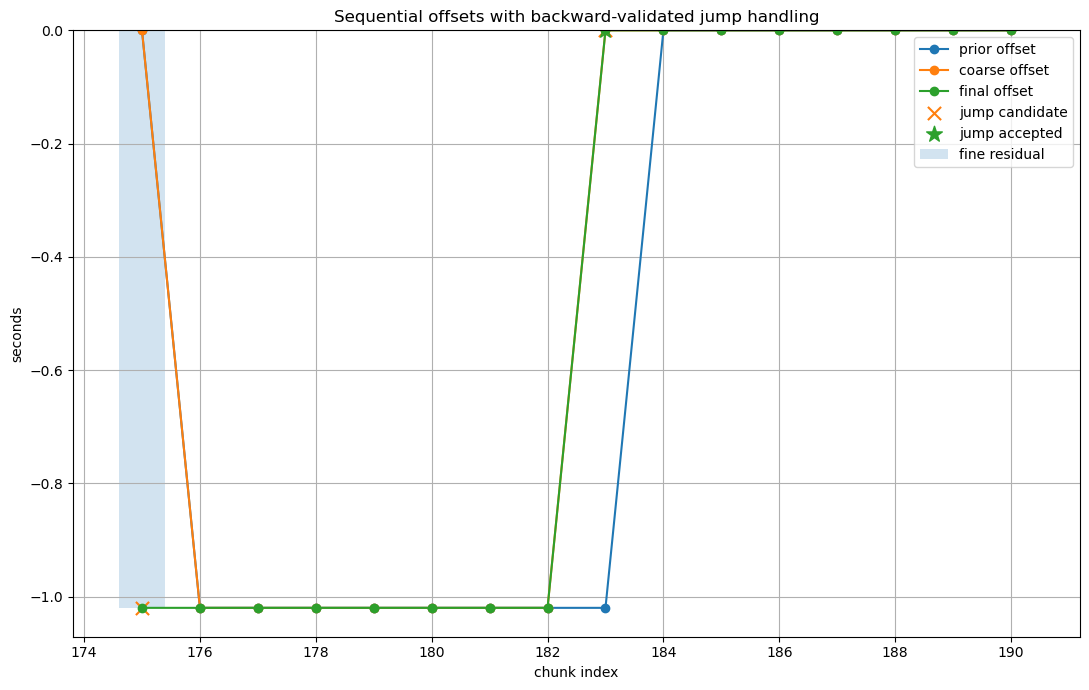

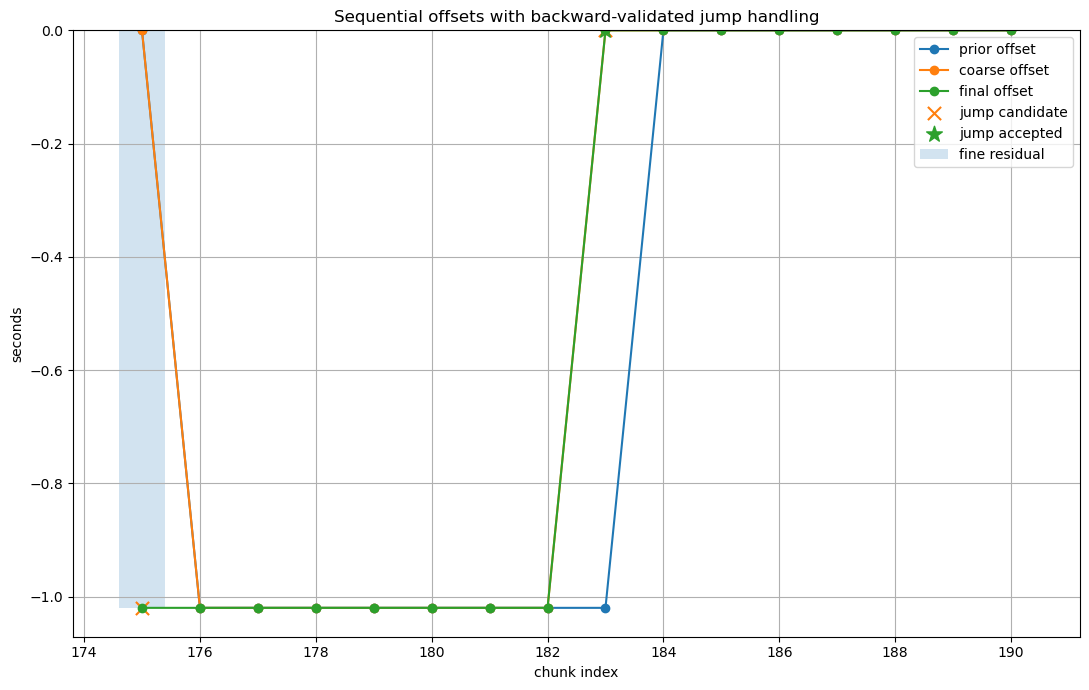

In [ ]:
# sequential offsets + 20 Hz native refinement + NetCDF save
seq_count = min(length(icvn), 16)
ic_seq = collect(icvn[1:seq_count])
beams_seq = init_periodic_beams(nx, nz)
seq_results = run_sequential_offsets(
    beams_seq, Env, Vn, UV, ic_seq;
    ntop=nz,
    jump_threshold_seconds=0.8,
    min_fine_peak=0.08,
    backward_windows=2,
    backward_tol=0.35,
    )

state_ref = init_stream_state()
seq_ref20 = NamedTuple[]
for r in seq_results
    w = extract_sync_window(beams_seq, Env, state_ref, Vn, UV, r.ic; ntop=nz)
    s1 = coarse_and_fine_lag(w.mdv, w.vn2; prior_seconds=r.prior_offset)
    rf = refine_offset_20hz(w, s1, Vn)
    push!(seq_ref20, (;
        r...,
        final_offset_20hz=rf.final_offset_20hz,
        final_offset_native=rf.final_offset_native,
        final_offset_round_s=rf.final_offset_round_s,
        vn2_1s_aligned=rf.vn2_1s_aligned,
        mdv_residual_1s=rf.mdv_residual_1s,
    ))
end

seq_ic = [r.ic for r in seq_ref20]
seq_prior = [r.prior_offset for r in seq_ref20]
seq_coarse = [r.coarse_offset for r in seq_ref20]
seq_final = [r.final_offset for r in seq_ref20]
seq_final_native = [r.final_offset_native for r in seq_ref20]
seq_final_round_s = [r.final_offset_round_s for r in seq_ref20]
seq_fine = [r.fine_residual for r in seq_ref20]
seq_jump_candidate = [r.jump_candidate for r in seq_ref20]
seq_jump_accepted = [r.jump_accepted for r in seq_ref20]

for r in seq_ref20
    @printf("ic=%d prior=%6.2f final1s=%6.2f final20=%6.2f round=%4d jump(cand/ok)=%s/%s\n",
        r.ic, r.prior_offset, r.final_offset, r.final_offset_native, r.final_offset_round_s,
        string(r.jump_candidate), string(r.jump_accepted))
end

total_time_offsets_round_s = seq_final_round_s
total_time_offsets_native_s = seq_final_native

maxlen = maximum(length(r.vn2_1s_aligned) for r in seq_ref20)
vn1s_aligned_matrix = fill(Float32(NaN), length(seq_ref20), maxlen)
mdv_residual_matrix = fill(Float32(NaN), length(seq_ref20), maxlen)
for (i, r) in enumerate(seq_ref20)
    n = length(r.vn2_1s_aligned)
    vn1s_aligned_matrix[i, 1:n] .= Float32.(r.vn2_1s_aligned)
    mdv_residual_matrix[i, 1:n] .= Float32.(r.mdv_residual_1s)
end

nc_out = joinpath("epsilon_data", "vn_sync_offsets.nc")
ds = NCDataset(nc_out, "c")
defDim(ds, "chunk", length(seq_ref20))
defDim(ds, "time", maxlen)
v_ic = defVar(ds, "chunk_index", Int32, ("chunk",))
v_t0 = defVar(ds, "chunk_start_epoch_ms", Int64, ("chunk",))
v_off1 = defVar(ds, "offset_1hz_s", Float64, ("chunk",))
v_off20 = defVar(ds, "offset_20hz_native_s", Float64, ("chunk",))
v_offr = defVar(ds, "offset_round_s", Int32, ("chunk",))
v_vn1 = defVar(ds, "vn2_1s_aligned", Float32, ("chunk", "time"))
v_res = defVar(ds, "mdv_plus_vn2_1s", Float32, ("chunk", "time"))

v_ic[:] = Int32.(seq_ic)
v_t0[:] = Int64.(Dates.datetime2epochms.([r.start_dt for r in seq_ref20]))
v_off1[:] = Float64.(seq_final)
v_off20[:] = Float64.(seq_final_native)
v_offr[:] = Int32.(seq_final_round_s)
v_vn1[:, :] = vn1s_aligned_matrix
v_res[:, :] = mdv_residual_matrix
ds.attrib["description"] = "Lidar-VN timing offsets with 20 Hz refinement and 1-second aligned VN series"
close(ds)

fig = figure(figsize=(11, 7))
clf()
plot(seq_ic, seq_prior, marker="o", label="prior offset")
plot(seq_ic, seq_coarse, marker="o", label="coarse offset")
plot(seq_ic, seq_final, marker="o", label="final offset (1 Hz)")
plot(seq_ic, seq_final_native, marker="o", label="final offset (20 Hz native)")
bar(seq_ic, seq_fine, alpha=0.20, label="fine residual")

if any(seq_jump_candidate)
    jc_x = seq_ic[seq_jump_candidate]
    jc_y = seq_final_native[seq_jump_candidate]
    scatter(jc_x, jc_y, marker="x", s=90, label="jump candidate")
end
if any(seq_jump_accepted)
    ja_x = seq_ic[seq_jump_accepted]
    ja_y = seq_final_native[seq_jump_accepted]
    scatter(ja_x, ja_y, marker="*", s=140, label="jump accepted")
end

xlabel("chunk index")
ylabel("seconds")
title("Sequential offsets with 20 Hz native refinement")
legend()
grid(true)
tight_layout()
println("Saved: ", nc_out)
gcf()

## Next Steps

The notebook now includes:

- iterative coarse envelope alignment
- explicit coarse-shift application before the fine FFT cross-correlation
- sequential priors from the previous accepted window, a 10-minute history, and the current parent hour

The main remaining work is:

- add jump detection and confidence-based fallback when the sequential prior fails
- expand the sequential diagnostic subset into the full production loop
- save per-window timing outputs and diagnostic confidence fields for later integration